In [56]:
import pandas as pd
import os

In [57]:
# load result csv files from the result_data folder
results = pd.read_csv("../result_data/skellam_fusion_test_predictions.csv")


In [58]:
# create new column: true_result, which shows whether HG or AG is greater
# thus: if HG > AG, true_result = 1
# if HG < AG, true_result = -1
# if HG == AG, true_result = 0
results['true_result'] = results.apply(lambda row: 1 if row['HG'] > row['AG'] else (-1 if row['HG'] < row['AG'] else 0), axis=1)

# create new column: predicted_result, which shows whether lambda_home or lambda_away is greater
# thus: if lambda_home > lambda_away, predicted_result = 1
# if lambda_home < lambda_away, predicted_result = -1
# draw is declared, if the difference between lambda_home and lambda_away is less than xx

# escaping the draw trap:
# set t such that 25% of the predictions are draws
t = results.apply(lambda row: abs(row['lambda_home'] - row['lambda_away']), axis=1).quantile(0.25)
results['predicted_result'] = results.apply(lambda row: 1 if row['lambda_home'] > row['lambda_away'] + t else (-1 if row['lambda_home'] < row['lambda_away'] - t else 0), axis=1)


In [59]:
# calculate accuracy of the predictions
accuracy = (results['true_result'] == results['predicted_result']).mean()
accuracy

np.float64(0.598)

In [60]:
results

,game_id,HG,AG,lambda_home,lambda_away,expected_goal_diff,true_result,predicted_result
0,20250815_GIR_RAY,1.0,3.0,1.522141,1.270539,0.251601,-1,1
1,20250815_LIV_BOU,4.0,2.0,1.943646,1.267728,0.675918,1,1
2,20250815_REN_OM,1.0,0.0,1.030403,1.222776,-0.192373,1,-1
3,20250816_ALA_LEV,2.0,1.0,1.390441,1.231645,0.158796,1,1
4,20250816_ASM_HAC,3.0,1.0,1.951172,1.245867,0.705306,1,1
...,...,...,...,...,...,...,...,...
1495,20260504_CHE_NFO,1.0,3.0,1.719179,1.261801,0.457378,-1,1
1496,20260504_CRE_LAZ,1.0,2.0,1.250446,1.218771,0.031675,-1,0
1497,20260504_EVE_MCI,3.0,3.0,0.884301,1.213529,-0.329228,0,-1
1498,20260504_ROM_FIO,4.0,0.0,2.181676,1.312287,0.869389,1,1


Total true home wins: 663
Total true draws: 375
Total true away wins: 462


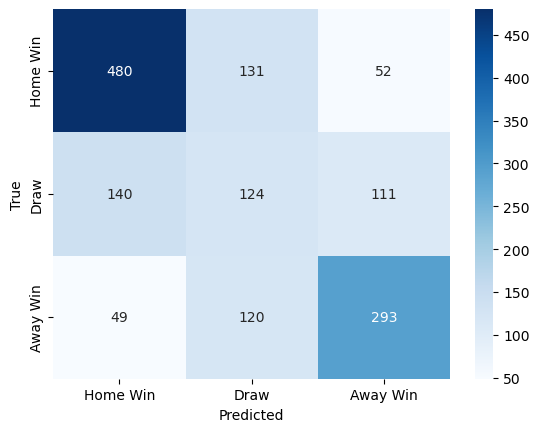

In [61]:
# create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(results['true_result'], results['predicted_result'], labels=[1, 0, -1])

# display better readable confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(results['true_result'], results['predicted_result'], labels=[1, 0, -1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Home Win', 'Draw', 'Away Win'], yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.xlabel('Predicted')
plt.ylabel('True')

# compute total number of true home wins, draws, and away wins
true_home_wins = (results['true_result'] == 1).sum()
true_draws = (results['true_result'] == 0).sum()
true_away_wins = (results['true_result'] == -1).sum()

print(f"Total true home wins: {true_home_wins}")
print(f"Total true draws: {true_draws}")
print(f"Total true away wins: {true_away_wins}")


In [63]:
# calculate MAE and MSE for the predicted lambdas
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_home = mean_absolute_error(results['HG'], results['lambda_home'])
mae_away = mean_absolute_error(results['AG'], results['lambda_away'])
mse_home = mean_squared_error(results['HG'], results['lambda_home'])
mse_away = mean_squared_error(results['AG'], results['lambda_away'])    
print(f"MAE Home: {mae_home}, MAE Away: {mae_away}")
print(f"MSE Home: {mse_home}, MSE Away: {mse_away}")

MAE Home: 0.8466902415752411, MAE Away: 0.9159341806570689
MSE Home: 1.1736202620237097, MSE Away: 1.3456753854003722


## Diagnostics by league and season

In [ ]:
# Add league/season identifiers to results from game_id
from pathlib import Path
import sys
import pandas as pd

# Ensure project root is importable when running from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.game_id_context import infer_league_and_season

# Resolve context for each game_id and merge into results
context_df = results["game_id"].astype(str).apply(infer_league_and_season).apply(pd.Series)
results = results.drop(columns=["league", "season"], errors="ignore").merge(
    context_df[["game_id", "league", "season"]], on="game_id", how="left"
 )

# Quick check
results

,game_id,league,season
0,20250815_GIR_RAY,Spain La Liga,2025-2026
1,20250815_LIV_BOU,England Premier League,2025-2026
2,20250815_REN_OM,France Ligue 1,2025-2026
3,20250816_ALA_LEV,Spain La Liga,2025-2026
4,20250816_ASM_HAC,France Ligue 1,2025-2026
5,20250816_AVL_NEW,England Premier League,2025-2026
6,20250816_BHA_FUL,England Premier League,2025-2026
7,20250816_MLL_FCB,Spain La Liga,2025-2026
8,20250816_NIC_TFC,France Ligue 1,2025-2026
9,20250816_RCL_OL,France Ligue 1,2025-2026


In [66]:
# calculate accuracy by league (season is always the same, since we only have one season in the test set)
accuracy_by_league = results.groupby("league").apply(
    lambda x: (x['true_result'] == x['predicted_result']).mean()
).reset_index(name="accuracy")

print(accuracy_by_league)

                   league  accuracy
0  England Premier League  0.570064
1          France Ligue 1  0.592058
2      Germany Bundesliga  0.634752
3           Italy Serie A  0.595016
4           Spain La Liga  0.601307


/var/folders/dd/nkyzffbd1gdfdc7t3v9nd1840000gn/T/ipykernel_33405/247904003.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_league = results.groupby("league").apply(
